# RNA velocity of FUCCI

References:
* https://www.nature.com/articles/s41586-021-03232-9
* https://github.com/CellProfiling/FucciSingleCellSeqPipeline
* https://drive.google.com/file/d/149ICTtieYjuKWZoLwRLzimwff0n6eWqw/view

## Setup

In [1]:
import scvelo as scv
import scanpy as sc
import pandas as pd
#import numpy as np
import anndata as ad
#from scipy import sparse
#import glob, os

scv.settings.verbosity = 3 # show errors(0), warnings(1), info(2), hints(3)
scv.settings.presenter_view = True # set max width size for presenter view
scv.settings.set_figure_params('scvelo') # for beautified visualization

## Load loom

In [ ]:
# RNAData/a.loom in input.zip
adata = sc.read_loom("../data/fucci_RNAData.loom")
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 1152 × 58884
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    layers: 'matrix', 'ambiguous', 'spanning', 'spliced', 'unspliced'

## Check whether X is spliced count

In [4]:
adata.X.sum(), adata.layers["spliced"].sum(), adata.layers["unspliced"].sum()

(327662140.0, 327662147, 57760606)

## RNA velocity

calculating cell cycle phase
-->     'S_score' and 'G2M_score', scores of cell cycle phases (adata.obs)
Filtered out 38278 genes that are detected 20 counts (spliced).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.


/tmp/ipykernel_1184953/3816937708.py:13: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


computing neighbors
    finished (0:00:11) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 32/48 cores)


/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


  0%|          | 0/1152 [00:00<?, ?cells/s]

    finished (0:00:48) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


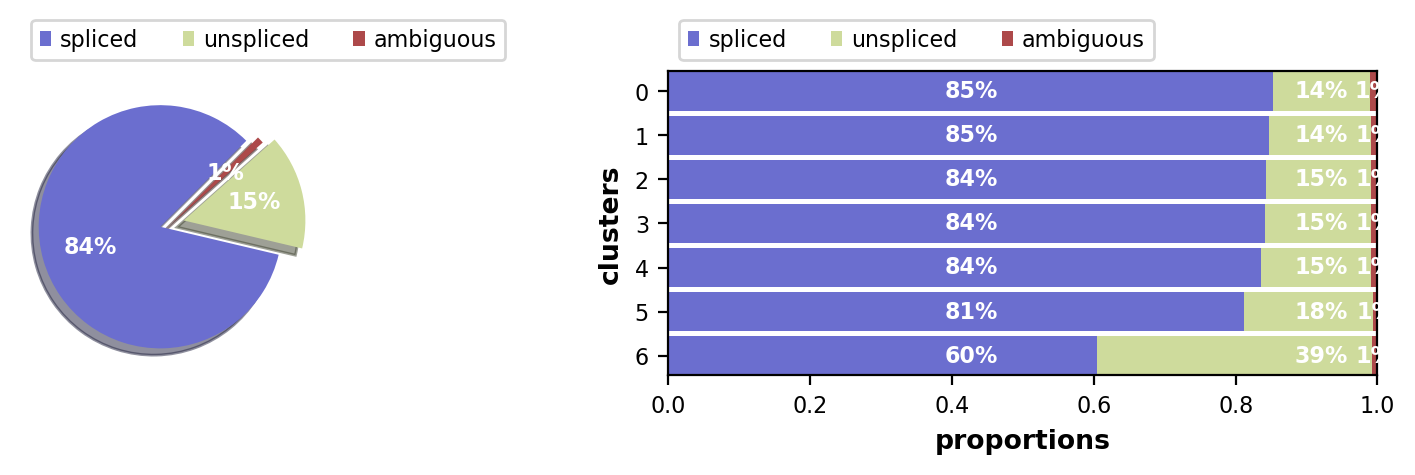

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_pca', embedded velocity vectors (adata.obsm)


/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/plo

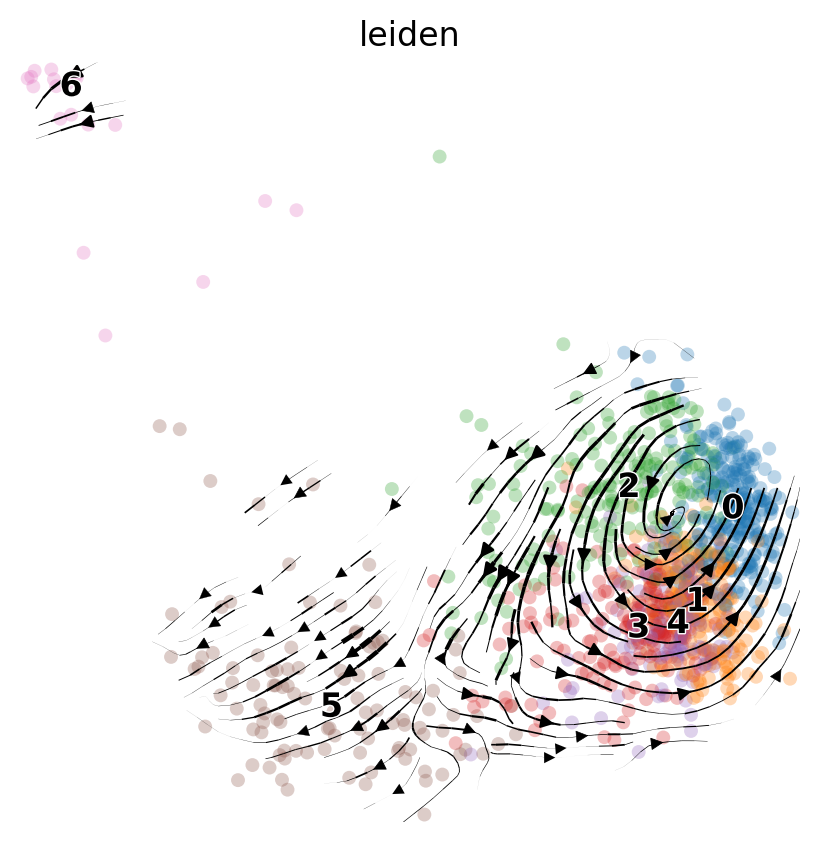

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/plo

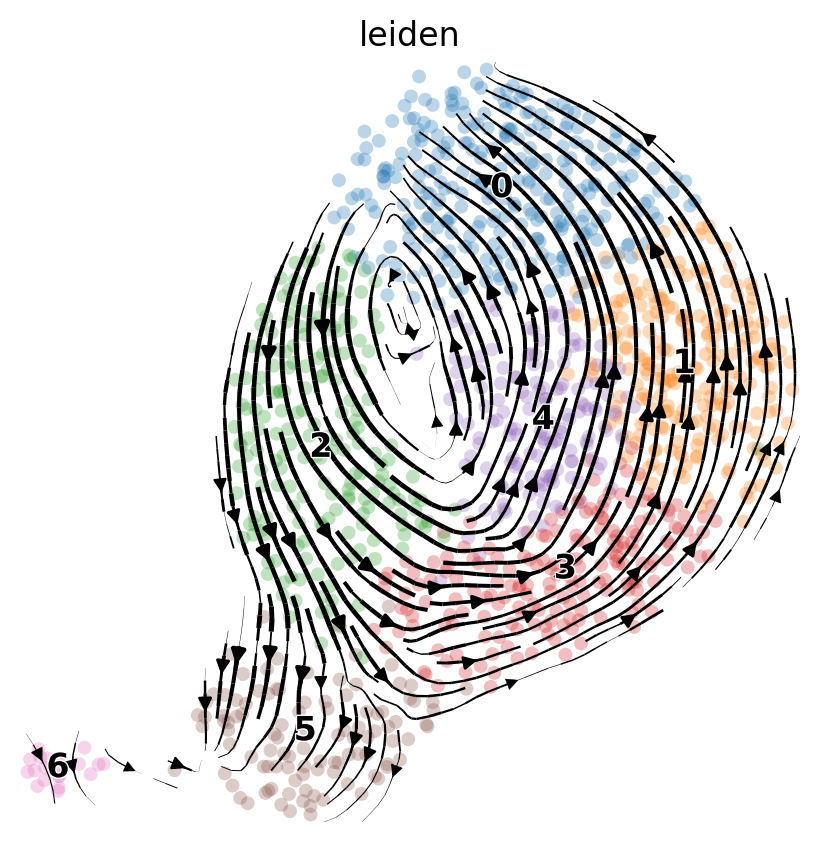

In [5]:
adata.raw = adata
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
#sc.pp.filter_cells(adata, min_genes=500)
scv.tl.score_genes_cell_cycle(adata)
#sc.pp.filter_genes(adata, min_cells=10)
scv.pp.filter_genes(adata, min_counts=20)
scv.pp.normalize_per_cell(adata)
#sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
scv.pp.filter_genes_dispersion(adata, n_top_genes=2000) # 3000 in Qiu
#scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
sc.tl.pca(adata)
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
#sc.pp.neighbors(adata, n_pcs=30, n_neighbors=30)
#scv.pp.moments(adata, n_pcs=None, n_neighbors=None)
#scv.tl.recover_dynamics(adata,n_jobs=32)
#scv.tl.velocity(adata,mode="dynamical")
scv.tl.velocity(adata,mode="stochastic")
scv.tl.velocity_graph(adata,n_jobs=32)
sc.tl.umap(adata,min_dist=0.8,maxiter=500,random_state=1231)
sc.tl.leiden(adata)
adata.obs["clusters"] = adata.obs["leiden"]
scv.pl.proportions(adata,groupby='clusters')
#scv.pl.scatter(adata, color_gradients=['S_score', 'G2M_score'], smooth=True, perc=[5, 95],figsize=(5,5))
scv.pl.velocity_embedding_stream(adata, basis='pca',  color='leiden',size=100,figsize=(5,5))
scv.pl.velocity_embedding_stream(adata, basis='umap', color='leiden',size=100,figsize=(5,5))

In [6]:
adata.write("../data/scvelo_fucci.h5ad")